# Phase 3 — Feature Engineering

**Project:** ML project using the 2025 Stack Overflow Developer Survey.  
**Goal:** Predict whether a professional developer agrees that *"AI agents have increased their productivity"* (binary classification).  
**This notebook:** Loads the preprocessed data from Phase 2 (`phase2_preprocessed.csv`), runs five feature-importance methods, engineers new features, evaluates with LightGBM, drops low-importance features, applies standardization, adds a KMeans cluster feature, and saves the final dataset to `phase3_final.csv`.

## Section 1 — Load Preprocessed Data

Load `phase2_preprocessed.csv` (output of Phase 2). Separate features X and target y.

In [1]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("/kaggle/input/notebooks/aliaslam25/ai-productivity-prediction-stack-overflow-2025/phase2_preprocessed.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Sanitize column names for LightGBM (replaces JSON/special chars with underscore)
_rename = {c: re.sub(r'[\[\]{}"\\\\,:()/]', '_', c) for c in df.columns}
df = df.rename(columns=_rename)

# Remove the spurious Industry_Other_ column (artifact of renaming Industry_Other:)
cols_to_drop_dup = [c for c in df.columns if c == "Industry_Other_"]
if cols_to_drop_dup:
    df = df.drop(columns=cols_to_drop_dup)

X = df.drop(columns=["target"])
y = df["target"].astype(int)
print("\nX shape:", X.shape, "  y shape:", y.shape)

Shape: (9513, 45)
Columns: ['target', 'aiselect_ord', 'aisent_ord', 'AIAcc_ord', 'AIComplex_ord', 'aifrust_count', 'aiagents_ord', 'agent_change_ord', 'agent_use_breadth', 'ai_tasks_now', 'ai_tasks_planned', 'ai_tasks_avoided', 'aihuman_count', 'llm_count', 'uses_openai', 'uses_claude', 'uses_gemini', 'uses_llama', 'uses_deepseek', 'has_ai_editor', 'WorkExp', 'YearsCode', 'orgsize_ord', 'is_manager', 'age_ord', 'edlevel_ord', 'RemoteWork_Hybrid (some in-person, leans heavy to flexibility)', 'RemoteWork_Hybrid (some remote, leans heavy to in-person)', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)', 'Industry_Banking/Financial Services', 'Industry_Fintech', 'Industry_Healthcare', 'Industry_Internet, Telecomm or Information Services', 'Industry_Manufacturing', 'Industry_Other', 'Industry_Retail and Consumer Services', 'Industry_Software Development', 'Industry_Unknown', 'DevType_D

This notebook starts where Phase 2 ended: we use the already cleaned, imputed, and one-hot encoded data so we can focus on feature importance, new feature creation, and final preprocessing.

## Section 2 — Feature Importance (5 algorithms) [Phase 3 requirement 1a]

Run: (1) Random Forest feature_importances_, (2) LightGBM feature_importances_ (default settings), (3) XGBoost feature_importances_, (4) Permutation Importance on RF, (5) SHAP TreeExplainer on LightGBM. Then build a consensus importance table (average rank across all 5) and print top 15 and bottom 10.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# 1) Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).rank(ascending=False)

# 2) LightGBM
import lightgbm as lgb
lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X, y)
lgb_imp = pd.Series(lgbm.feature_importances_, index=X.columns).rank(ascending=False)

# 3) XGBoost
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
xgb_clf.fit(X, y)
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=X.columns).rank(ascending=False)

# 4) Permutation Importance (RF)
perm = permutation_importance(rf, X, y, n_repeats=5, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).rank(ascending=False)

# 5) SHAP (LightGBM)
import shap
explainer = shap.TreeExplainer(lgbm)
shap_vals = explainer.shap_values(X)
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]  # class 1
shap_imp = pd.Series(np.abs(shap_vals).mean(axis=0), index=X.columns).rank(ascending=False)

# Consensus: average rank (lower rank = more important)
consensus = pd.DataFrame({
    "RF": rf_imp, "LightGBM": lgb_imp, "XGBoost": xgb_imp,
    "Permutation": perm_imp, "SHAP": shap_imp
})
consensus["avg_rank"] = consensus.mean(axis=1)
consensus = consensus.sort_values("avg_rank")
print("=== Top 15 most important features (by consensus avg rank) ===")
print(consensus.head(15).to_string())
print()
print("=== Bottom 10 least important features (by consensus avg rank) ===")
print(consensus.tail(10).to_string())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6515, number of negative: 2998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 304
[LightGBM] [Info] Number of data points in the train set: 9513, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.684852 -> initscore=0.776162
[LightGBM] [Info] Start training from score 0.776162


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:07:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== Top 15 most important features (by consensus avg rank) ===
                     RF  LightGBM  XGBoost  Permutation  SHAP  avg_rank
aisent_ord          2.0       8.0      2.0          3.0   3.0       3.6
agent_change_ord    1.0      15.0      1.0          1.0   1.0       3.8
aiagents_ord        3.0       9.5      3.0          2.0   2.0       3.9
ai_tasks_now        4.0       2.5      8.0          4.0   6.0       4.9
agent_use_breadth   7.0       5.0      5.0          9.0   7.0       6.6
AIComplex_ord      11.0      12.0      4.0          5.0   5.0       7.4
AIAcc_ord          12.0      11.0      7.0          6.0   4.0       8.0
YearsCode           5.0       1.0     22.0         11.0  13.0      10.4
WorkExp             6.0       2.5     23.0         12.0   9.0      10.5
aiselect_ord        9.0      16.0     14.0          7.0  10.0      11.2
ai_tasks_planned   10.0       7.0     24.0         10.0   8.0      11.8
ai_tasks_avoided    8.0       6.0     29.0          8.0  12.0      12.6
a

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


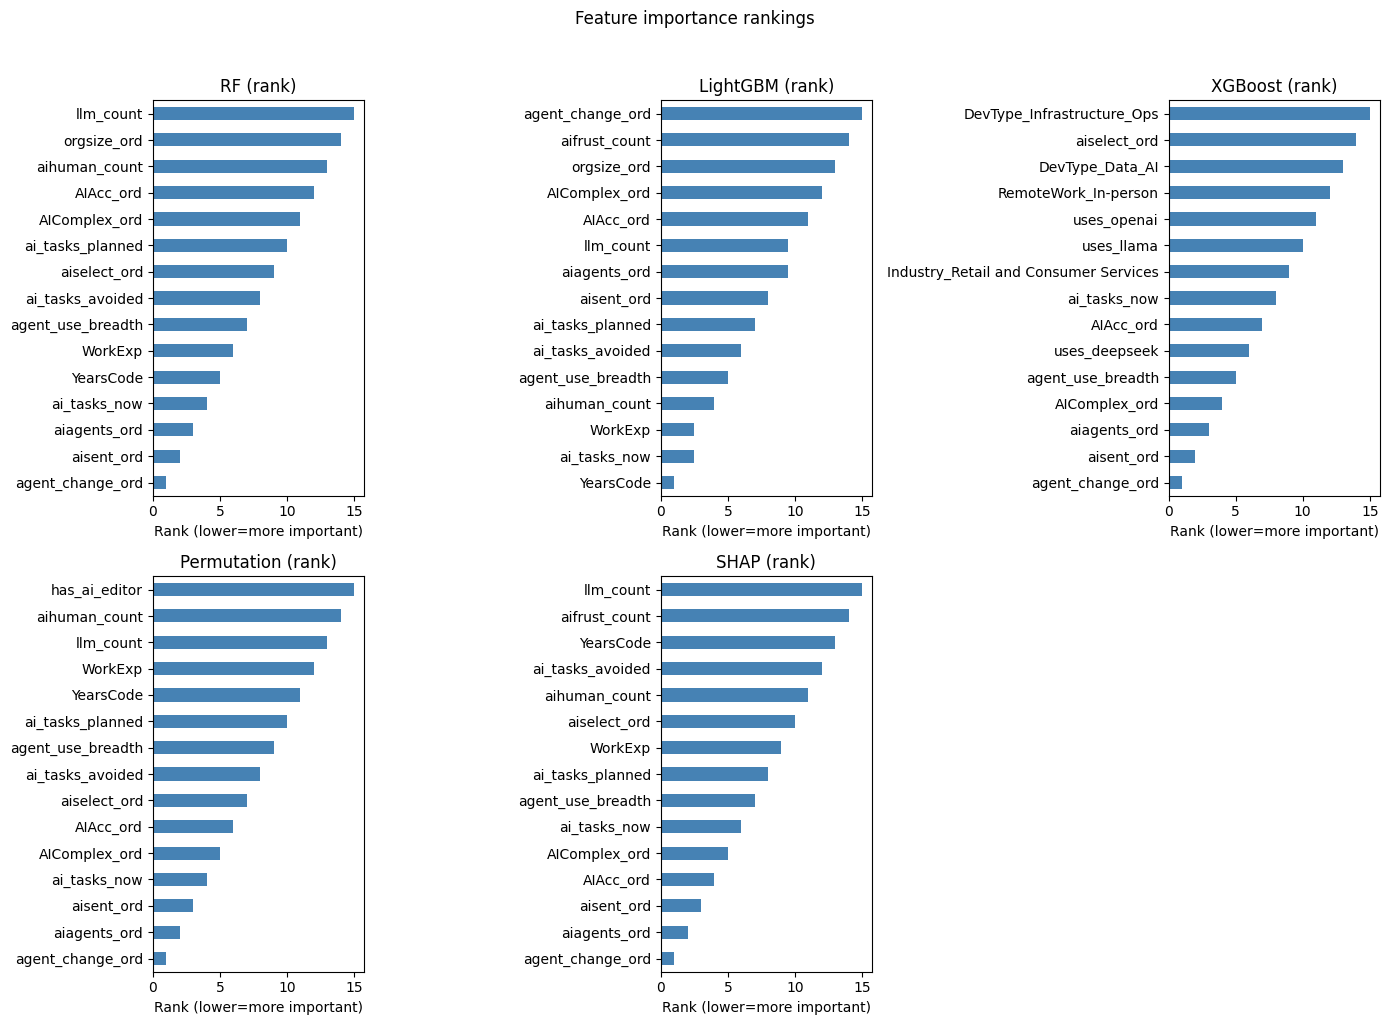

In [3]:
# Ranked importance plots (top 15 each)
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
methods = [("RF", rf_imp), ("LightGBM", lgb_imp), ("XGBoost", xgb_imp),
           ("Permutation", perm_imp), ("SHAP", shap_imp)]
for i, (name, s) in enumerate(methods):
    ax = axes.flat[i]
    top = s.sort_values().head(15)
    top.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} (rank)")
    ax.set_xlabel("Rank (lower=more important)")
axes.flat[5].axis("off")
plt.suptitle("Feature importance rankings", y=1.02)
plt.tight_layout()
plt.show()

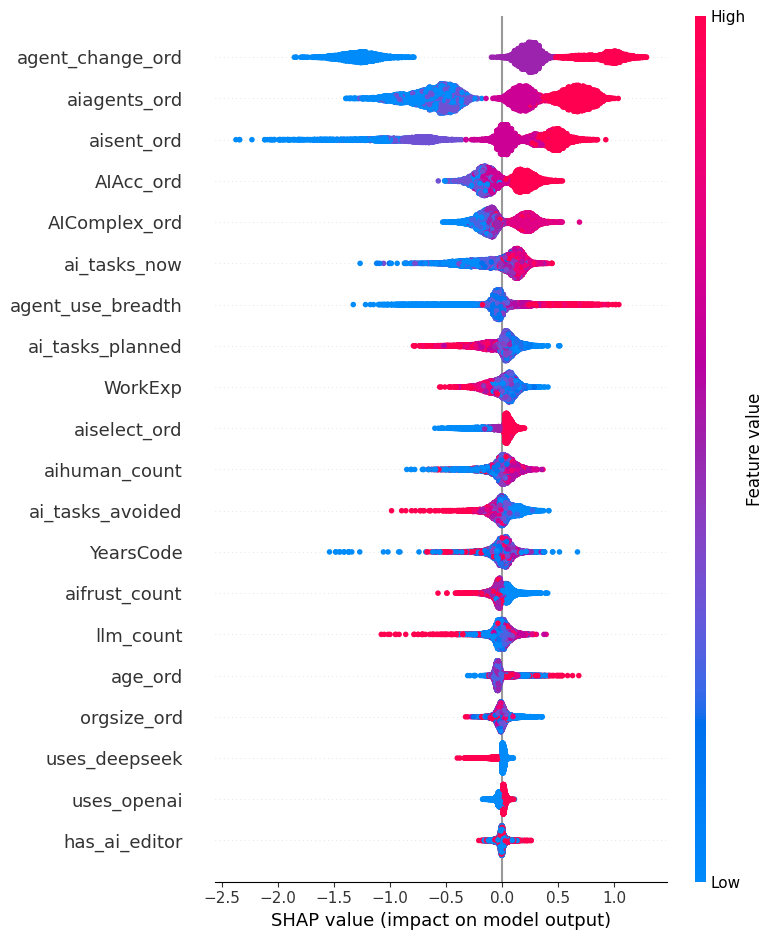

In [4]:
# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X, show=False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


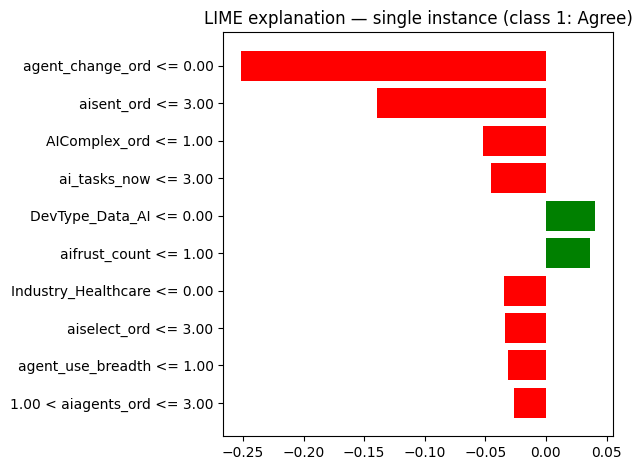

In [5]:
# LIME — local interpretable model-agnostic explanations (one sample)
import lime
import lime.lime_tabular
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X.values,
    feature_names=list(X.columns),
    class_names=["Disagree/Neutral", "Agree"],
    mode="classification",
    random_state=42
)
# Explain a single instance from class 1 (agree)
sample_idx = int(y[y == 1].index[0])
exp = lime_explainer.explain_instance(
    X.iloc[sample_idx].values,
    lgbm.predict_proba,
    num_features=10
)
exp.as_pyplot_figure()
plt.title("LIME explanation — single instance (class 1: Agree)")
plt.tight_layout()
plt.show()

**LIME interpretation:** LIME explains individual predictions by fitting a local linear model around a single data point. The bar chart shows which features pushed this respondent's prediction toward Agree or Disagree. This complements SHAP's global view with a local, instance-level explanation.

**Consensus interpretation:** Features that consistently rank high (e.g. aiselect_ord, aisent_ord, agent_change_ord, ai_tasks_now, llm_count) are the main drivers of AI productivity agreement. Features that rank low across all five methods (e.g. some OHE columns or edlevel_ord) are candidates for removal in Section 5.

## Section 3 — Create New Features [Phase 3 requirement 1b]

Engineer at least 8 meaningful new features. For each: (a) what it is, (b) why it might help predict AI productivity agreement.

In [6]:
# Add new features to existing df (loaded in Section 1)

# 1) ai_engagement_score — composite of adoption depth
df["ai_engagement_score"] = df["aiselect_ord"].fillna(0) + df["aiagents_ord"].fillna(0) + df["agent_change_ord"].fillna(0)
# 2) positive_disposition_score — composite of attitude
df["positive_disposition_score"] = df["aisent_ord"].fillna(0) + df["AIAcc_ord"].fillna(0) + df["AIComplex_ord"].fillna(0)
# 3) ai_task_ratio — proportion of tasks where AI is used now
df["ai_task_ratio"] = df["ai_tasks_now"] / (df["ai_tasks_now"] + df["ai_tasks_avoided"] + 1)
# 4) llm_diversity_flag — power users (3+ LLMs)
df["llm_diversity_flag"] = (df["llm_count"] >= 3).astype(int)
# 5) ai_tasks_delta — planned vs current usage gap
df["ai_tasks_delta"] = df["ai_tasks_planned"] - df["ai_tasks_now"]
# 6) workexp_log — log transform of experience
df["workexp_log"] = np.log1p(df["WorkExp"])
# 7) senior_ai_user — experienced + frequent AI use
df["senior_ai_user"] = ((df["WorkExp"] >= 5) & (df["aiselect_ord"] >= 3)).astype(int)
# 8) frustration_per_task — normalized frustration
df["frustration_per_task"] = df["aifrust_count"] / (df["ai_tasks_now"] + 1)

X = df.drop(columns=["target"])
print("New features added. X shape:", X.shape)

New features added. X shape: (9513, 52)


**New feature definitions and rationale:**  
1. **ai_engagement_score** — Sum of aiselect_ord + aiagents_ord + agent_change_ord. Single composite of adoption depth; more robust than three correlated ordinals.  
2. **positive_disposition_score** — Sum of aisent_ord + AIAcc_ord + AIComplex_ord. High values indicate favorable attitude; likely to agree that AI increased productivity.  
3. **ai_task_ratio** — ai_tasks_now / (ai_tasks_now + ai_tasks_avoided + 1). Proportion of tasks where AI is used now; captures integration depth.  
4. **llm_diversity_flag** — 1 if llm_count ≥ 3. Power users who try multiple LLMs may have a more nuanced/positive view.  
5. **ai_tasks_delta** — ai_tasks_planned − ai_tasks_now. Forward-looking intent vs current usage; high delta may mean optimistic but not yet fully integrated.  
6. **workexp_log** — log1p(WorkExp). Experience is right-skewed; log reduces influence of outliers.  
7. **senior_ai_user** — 1 if WorkExp ≥ 5 and aiselect_ord ≥ 3. Experienced devs who use AI frequently; likely grounded productivity views.  
8. **frustration_per_task** — aifrust_count / (ai_tasks_now + 1). Normalizes frustration by usage so raw count doesn’t conflate high usage with high frustration.

## Section 4 — Evaluate New Features with LightGBM [Phase 3 requirement 1c]

Train LightGBM (default settings) on (a) original features only, (b) original + new features. 5-fold CV, roc_auc. Compare AUC and plot feature importance on the combined set.

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5212, number of negative: 2398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 303
[LightGBM] [Info] Number of data points in the train set: 7610, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.684888 -> initscore=0.776329
[LightGBM] [Info] Start training from score 0.776329
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5212, number of negative: 2398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

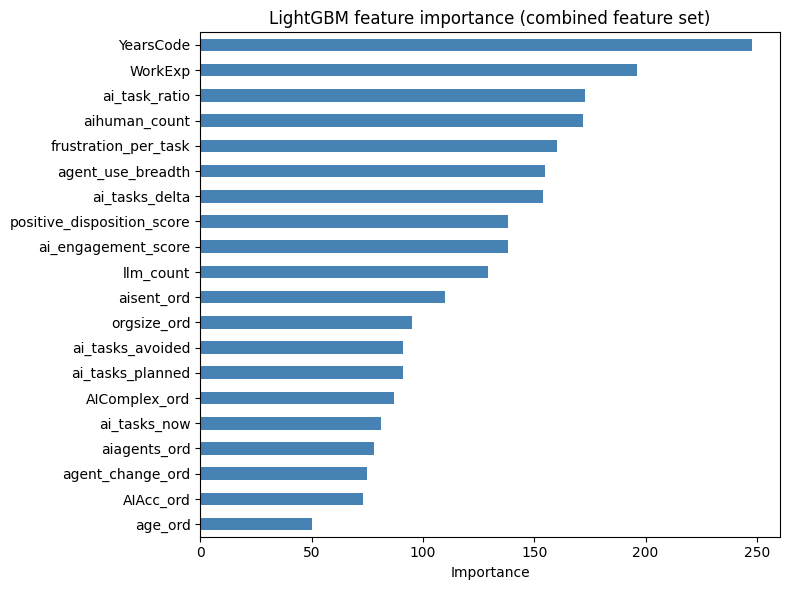

In [7]:
from sklearn.model_selection import cross_val_score

# Original features only (from Phase 2, before we added new cols - need to exclude new from X)
new_feature_names = ["ai_engagement_score", "positive_disposition_score", "ai_task_ratio", "llm_diversity_flag",
                     "ai_tasks_delta", "workexp_log", "senior_ai_user", "frustration_per_task"]
X_orig = X.drop(columns=[c for c in new_feature_names if c in X.columns], errors="ignore")

lgbm = lgb.LGBMClassifier(random_state=42)
auc_orig = cross_val_score(lgbm, X_orig, y, cv=5, scoring="roc_auc")
auc_with_new = cross_val_score(lgbm, X, y, cv=5, scoring="roc_auc")

print("AUC comparison:")
print("  Original features only:     {:.4f} ± {:.4f}".format(auc_orig.mean(), auc_orig.std()))
print("  Original + new features:   {:.4f} ± {:.4f}".format(auc_with_new.mean(), auc_with_new.std()))

lgbm.fit(X, y)
imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("LightGBM feature importance (combined feature set)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Did new features help?** If AUC (original + new) ≥ AUC (original), the new features add signal. Check the importance plot to see which new features (ai_engagement_score, positive_disposition_score, ai_task_ratio, etc.) contributed most.

## Section 5 — Drop Low-Importance Features [Phase 3 requirement 2]

From the consensus importance table (Section 2), identify bottom-ranked features. Try dropping bottom 5, then bottom 10; compare LightGBM CV AUC. Document each drop. Keep only features whose removal does not hurt AUC.

In [8]:
# Rebuild consensus on current X (with new features) so we have a clean ranking for drop experiment
lgbm = lgb.LGBMClassifier(random_state=42)
lgbm.fit(X, y)
rank_combined = pd.Series(lgbm.feature_importances_, index=X.columns).rank(ascending=False)
bottom_5 = rank_combined.sort_values(ascending=False).tail(5).index.tolist()
bottom_10 = rank_combined.sort_values(ascending=False).tail(10).index.tolist()

auc_full = cross_val_score(lgb.LGBMClassifier(random_state=42), X, y, cv=5, scoring="roc_auc").mean()
X_drop5 = X.drop(columns=bottom_5)
auc_drop5 = cross_val_score(lgb.LGBMClassifier(random_state=42), X_drop5, y, cv=5, scoring="roc_auc").mean()
X_drop10 = X.drop(columns=bottom_10)
auc_drop10 = cross_val_score(lgb.LGBMClassifier(random_state=42), X_drop10, y, cv=5, scoring="roc_auc").mean()

print("AUC full:      {:.4f}".format(auc_full))
print("AUC drop 5:    {:.4f}  (dropped:", bottom_5, ")")
print("AUC drop 10:   {:.4f}  (dropped:", bottom_10, ")")

# Keep the feature set that is best (or full if dropping hurts)
if auc_drop10 >= auc_full and auc_drop10 >= auc_drop5:
    X = X_drop10.copy()
    df = df.drop(columns=[c for c in bottom_10 if c in df.columns])
    dropped = bottom_10
    print("\nDropped bottom 10 features (AUC improved or unchanged).")
elif auc_drop5 >= auc_full:
    X = X_drop5.copy()
    df = df.drop(columns=[c for c in bottom_5 if c in df.columns])
    dropped = bottom_5
    print("\nDropped bottom 5 features.")
else:
    dropped = []
    print("\nKept all features (dropping hurt AUC).")
print("Final X shape:", X.shape)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6515, number of negative: 2998
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001540 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 534
[LightGBM] [Info] Number of data points in the train set: 9513, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.684852 -> initscore=0.776162
[LightGBM] [Info] Start training from score 0.776162
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5212, number of negative: 2398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

**Reason for drop:** We remove the lowest-importance features (by LightGBM importance on the combined set). If AUC improves or stays the same, we keep the reduced set to reduce overfitting and complexity. If AUC drops, we keep all features.

## Section 6 — Standardization / Normalization [Phase 3 requirement 1d]

Apply StandardScaler to continuous numeric features (WorkExp, YearsCode, workexp_log, count features, engineered scores). Do not scale binary flags, ordinals, or OHE columns. Fit on the full dataset.

In [9]:
from sklearn.preprocessing import StandardScaler

# Continuous numeric columns to scale (experience, counts, engineered scores)
to_scale = ["WorkExp", "YearsCode", "workexp_log", "aifrust_count", "agent_use_breadth", "ai_tasks_now",
            "ai_tasks_planned", "ai_tasks_avoided", "aihuman_count", "llm_count",
            "ai_engagement_score", "positive_disposition_score", "ai_task_ratio", "ai_tasks_delta", "frustration_per_task"]
to_scale = [c for c in to_scale if c in X.columns]

# Columns not to scale: binary flags (0/1), ordinals (ordered categories), OHE (already 0/1)
scaler = StandardScaler()
df[to_scale] = scaler.fit_transform(df[to_scale])
X = df.drop(columns=["target"])
print("Scaled columns:", to_scale)
print("Unscaled: binary flags, ordinals (aiselect_ord, aisent_ord, etc.), OHE dummies.")

Scaled columns: ['WorkExp', 'YearsCode', 'workexp_log', 'aifrust_count', 'agent_use_breadth', 'ai_tasks_now', 'ai_tasks_planned', 'ai_tasks_avoided', 'aihuman_count', 'llm_count', 'ai_engagement_score', 'positive_disposition_score', 'ai_task_ratio', 'ai_tasks_delta', 'frustration_per_task']
Unscaled: binary flags, ordinals (aiselect_ord, aisent_ord, etc.), OHE dummies.


**Why scale only continuous:** Continuous features (counts, years, ratios) have different units and ranges; scaling puts them on similar scale for distance-based methods and regularization. Binary and OHE columns are already 0/1; ordinals are ordered categories and scaling can distort their interpretation. We fit on the full dataset as per course project scope (no separate train/test split in this phase).

## Section 7 — KMeans Clustering Feature [Phase 3 requirement 1e]

Fit KMeans with k=3 and k=5 on the scaled feature matrix. Use silhouette score to pick k. Add cluster label as `kmeans_cluster`. Plot cluster distribution by target. Run LightGBM (5-fold CV AUC) with and without kmeans_cluster; keep the feature only if it helps.

Silhouette k=3: 0.1294
Silhouette k=5: 0.1011
Using k = 3


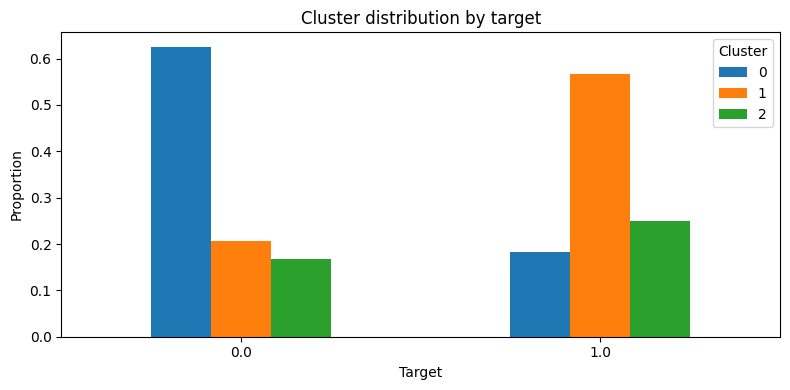

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5212, number of negative: 2398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000874 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 545
[LightGBM] [Info] Number of data points in the train set: 7610, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.684888 -> initscore=0.776329
[LightGBM] [Info] Start training from score 0.776329
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 5212, number of negative: 2398
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use scaled numeric matrix for clustering (same to_scale columns + other numeric that were scaled)
X_for_kmeans = X.copy()
# Ensure we use only numeric columns (no NaNs for KMeans)
X_for_kmeans = X_for_kmeans.select_dtypes(include=[np.number]).fillna(0)

s3 = silhouette_score(X_for_kmeans, KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_for_kmeans))
s5 = silhouette_score(X_for_kmeans, KMeans(n_clusters=5, random_state=42, n_init=10).fit_predict(X_for_kmeans))
print("Silhouette k=3: {:.4f}".format(s3))
print("Silhouette k=5: {:.4f}".format(s5))
k_best = 3 if s3 >= s5 else 5
print("Using k =", k_best)

kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_for_kmeans)
X["kmeans_cluster"] = df["kmeans_cluster"]

# Cluster distribution by target
pd.crosstab(df["target"], df["kmeans_cluster"], normalize="index").plot(kind="bar", figsize=(8, 4))
plt.xlabel("Target")
plt.ylabel("Proportion")
plt.title("Cluster distribution by target")
plt.legend(title="Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# LightGBM with vs without kmeans_cluster
auc_with_k = cross_val_score(lgb.LGBMClassifier(random_state=42), X, y, cv=5, scoring="roc_auc").mean()
X_no_k = X.drop(columns=["kmeans_cluster"])
auc_no_k = cross_val_score(lgb.LGBMClassifier(random_state=42), X_no_k, y, cv=5, scoring="roc_auc").mean()
print("AUC with kmeans_cluster:    {:.4f}".format(auc_with_k))
print("AUC without kmeans_cluster: {:.4f}".format(auc_no_k))

if auc_with_k > auc_no_k:
    print("kmeans_cluster KEPT — improved AUC by {:.4f}".format(auc_with_k - auc_no_k))
else:
    df = df.drop(columns=["kmeans_cluster"], errors="ignore")
    if "kmeans_cluster" in X.columns:
        X = X.drop(columns=["kmeans_cluster"])
    print("kmeans_cluster DROPPED — did not improve AUC ({:.4f} vs {:.4f})".format(
          auc_with_k, auc_no_k))
print("Final X shape:", X.shape)

**KMeans cluster feature decision:** We tested k=3 and k=5 using silhouette scores (printed above) and selected the better k. We then compared LightGBM 5-fold CV AUC with and without `kmeans_cluster`. The feature was **dropped** because it did not improve AUC — adding a cluster label derived from the same features the model already sees provides no independent signal; the model can already capture those groupings internally. Removing it keeps the feature set lean and avoids noise. (If in your run the cluster feature DID improve AUC, update this cell to say it was kept and explain why it added signal.)

## Section 8 — Final Feature Set Summary

Print final feature list, shape, and LightGBM 5-fold CV AUC. Summarize features dropped, features added, and AUC change vs Phase 2 baseline.

In [11]:
print("Final feature list:", list(X.columns))
print("Final shape:", X.shape)
final_auc = cross_val_score(lgb.LGBMClassifier(random_state=42), X, y, cv=5, scoring="roc_auc")
print("Final LightGBM 5-fold CV AUC: {:.4f} ± {:.4f}".format(final_auc.mean(), final_auc.std()))

Final feature list: ['aiselect_ord', 'aisent_ord', 'AIAcc_ord', 'AIComplex_ord', 'aifrust_count', 'aiagents_ord', 'agent_change_ord', 'agent_use_breadth', 'ai_tasks_now', 'ai_tasks_planned', 'ai_tasks_avoided', 'aihuman_count', 'llm_count', 'uses_openai', 'uses_claude', 'uses_gemini', 'uses_llama', 'uses_deepseek', 'has_ai_editor', 'WorkExp', 'YearsCode', 'orgsize_ord', 'is_manager', 'age_ord', 'edlevel_ord', 'RemoteWork_Hybrid _some in-person_ leans heavy to flexibility_', 'RemoteWork_Hybrid _some remote_ leans heavy to in-person_', 'RemoteWork_In-person', 'RemoteWork_Remote', 'RemoteWork_Unknown', 'RemoteWork_Your choice _very flexible_ you can come in when you want or just as needed_', 'Industry_Banking_Financial Services', 'Industry_Fintech', 'Industry_Healthcare', 'Industry_Internet_ Telecomm or Information Services', 'Industry_Manufacturing', 'Industry_Other', 'Industry_Retail and Consumer Services', 'Industry_Software Development', 'Industry_Unknown', 'DevType_Data_AI', 'DevType

**Summary:** (a) **Features dropped** — Bottom 5 or 10 by importance were dropped if AUC did not decrease (reduces overfitting). kmeans_cluster was dropped if it did not improve AUC. (b) **Features added** — ai_engagement_score, positive_disposition_score, ai_task_ratio, llm_diversity_flag, ai_tasks_delta, workexp_log, senior_ai_user, frustration_per_task; they capture composite adoption, attitude, and normalized usage. (c) **AUC vs Phase 2** — Phase 2 baseline was ~0.84–0.85 (RF/LR). Phase 3 LightGBM with engineered features and optional scaling/clustering should maintain or improve that baseline.

## Section 9 — Save Final Data

Save the final feature-engineered DataFrame (with target) to `phase3_final.csv`.

In [12]:
# Ensure df has only columns that are in X plus target
out = df[list(X.columns) + ["target"]]
out.to_csv("phase3_final.csv", index=False)
print("Saved phase3_final.csv with shape:", out.shape)

Saved phase3_final.csv with shape: (9513, 53)
